# Imports

In [8]:
!pip install keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from Utils.utils import loadData, reseed_grid_picker
from sklearn.model_selection import train_test_split
import pandas as pd
import keras_tuner as kt
from tqdm import tqdm
import os

# Load Dataset

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

# Keep the class-to-number mapping consistent across both folders.
train_images, train_targets, labels = loadData("train")
test_images, test_targets, _ = loadData("test", labels)

# Combine all labeled images before creating the assignment splits.
all_x = np.concatenate([train_images, test_images], axis=0)
all_y = np.concatenate([train_targets, test_targets], axis=0)

del train_images, train_targets, test_images, test_targets

# 70% training, 30% reserved for validation and testing.
train_x, remaining_x, train_y, remaining_y = train_test_split(
    all_x,
    all_y,
    test_size=0.30,
    random_state=42,
    stratify=all_y,
)

# Divide the remaining images equally into validation and testing.
val_x, test_x, val_y, test_y = train_test_split(
    remaining_x,
    remaining_y,
    test_size=0.50,
    random_state=42,
    stratify=remaining_y,
)

total_images = len(all_y)

for name, images, targets in [
    ("Training", train_x, train_y),
    ("Validation", val_x, val_y),
    ("Testing", test_x, test_y),
]:
    print(
        f"{name}: {len(targets):,} images "
        f"({len(targets) / total_images:.2%}), shape={images.shape}"
    )
    print("Class counts:", dict(zip(
        labels,
        np.bincount(targets, minlength=len(labels)),
    )))

del all_x, all_y, remaining_x, remaining_y

Training: 11,923 images (70.00%), shape=(11923, 64, 64, 3)
Class counts: {'buildings': 1839, 'forest': 1921, 'glacier': 2070, 'mountain': 2126, 'sea': 1949, 'street': 2018}
Validation: 2,555 images (15.00%), shape=(2555, 64, 64, 3)
Class counts: {'buildings': 395, 'forest': 412, 'glacier': 443, 'mountain': 455, 'sea': 418, 'street': 432}
Testing: 2,556 images (15.01%), shape=(2556, 64, 64, 3)
Class counts: {'buildings': 394, 'forest': 412, 'glacier': 444, 'mountain': 456, 'sea': 417, 'street': 433}


# Initial CNN testing

In [12]:
model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    keras.layers.Rescaling(1.0 / 255),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(256, 3, activation="relu"),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(labels),"softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
# optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,958 (1.49 MB)

 Trainable params: 389,958 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_x,
    train_y,
    epochs=20,
    batch_size=64,
    validation_data=(val_x, val_y),
    verbose=1,
)

Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.4790 - loss: 1.2591 - val_accuracy: 0.5597 - val_loss: 1.0983
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.6109 - loss: 0.9909 - val_accuracy: 0.6896 - val_loss: 0.8565
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.6742 - loss: 0.8716 - val_accuracy: 0.7018 - val_loss: 0.8119
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.7089 - loss: 0.7946 - val_accuracy: 0.7022 - val_loss: 0.7839
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.7328 - loss: 0.7360 - val_accuracy: 0.7299 - val_loss: 0.7606
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7517 - loss: 0.6884 - val_accuracy: 0.7652 - val_loss: 0.6577
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.7608 - loss: 0.6677 - val_accuracy: 0.7511 - val_loss: 0.6957
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.7745 - loss: 0.628

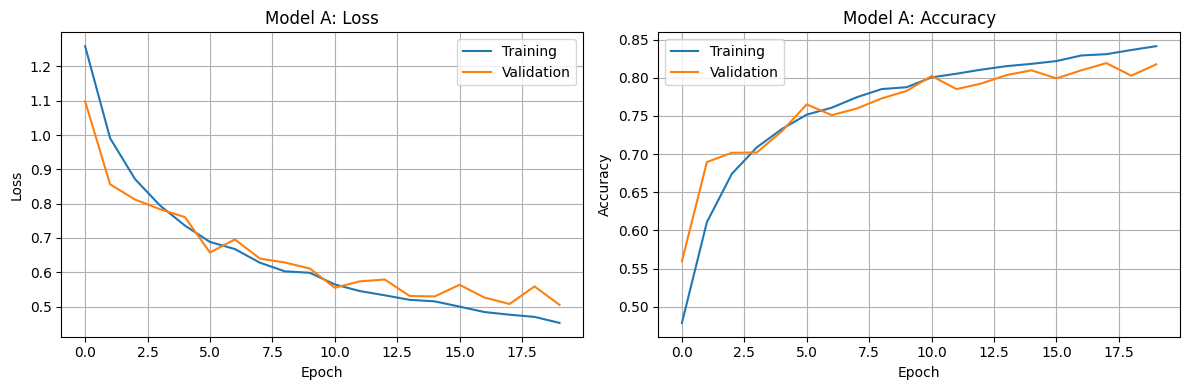

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(history.history[metric], label="Training")
    ax.plot(history.history[f"val_{metric}"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Model A: {metric.capitalize()}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Model A completed 20 epochs, achieving a final-epoch training accuracy of 84.14% and validation accuracy of 81.76%.

The test set has not yet been evaluated in this experiment. Further hyperparameter tuning will use validation results.

# Model B: Lightweight Depthwise Separable CNN

This model replaces standard convolutions with depthwise separable convolutions. It uses ReLU activations and global average pooling to limit computation and parameter count.

In [15]:
model_b = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    keras.layers.Rescaling(1.0 / 255),

    keras.layers.SeparableConv2D(
        32, 3, activation="relu", padding="same"
    ),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.SeparableConv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.SeparableConv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.SeparableConv2D(256, 3, activation="relu"),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(labels), activation="softmax"),
], name="model_b")

model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_params_b = sum(
    int(np.prod(weight.shape))
    for weight in model_b.trainable_weights
)

print(f"Model B trainable parameters: {trainable_params_b:,}")
assert trainable_params_b <= 100_000, "Model B exceeds the parameter limit!"

model_b.summary()

Model B trainable parameters: 47,169


Model: "model_b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 64, 64, 32)     │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 30, 30, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 13, 13, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 4, 4, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,169 (184.25 KB)

 Trainable params: 47,169 (184.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_b = model_b.fit(
    train_x,
    train_y,
    epochs=20,
    batch_size=64,
    validation_data=(val_x, val_y),
    verbose=1,
)

Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.2983 - loss: 1.6470 - val_accuracy: 0.4157 - val_loss: 1.3857
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.4426 - loss: 1.3300 - val_accuracy: 0.4951 - val_loss: 1.2139
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.5166 - loss: 1.1722 - val_accuracy: 0.5636 - val_loss: 1.0989
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.5687 - loss: 1.0854 - val_accuracy: 0.5953 - val_loss: 1.0415
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.5955 - loss: 1.0215 - val_accuracy: 0.6117 - val_loss: 0.9943
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.6063 - loss: 0.9899 - val_accuracy: 0.6145 - val_loss: 0.9640
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6190 - loss: 0.9612 - val_accuracy: 0.6270 - val_loss: 0.9273
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6372 - loss: 0.9309 - 

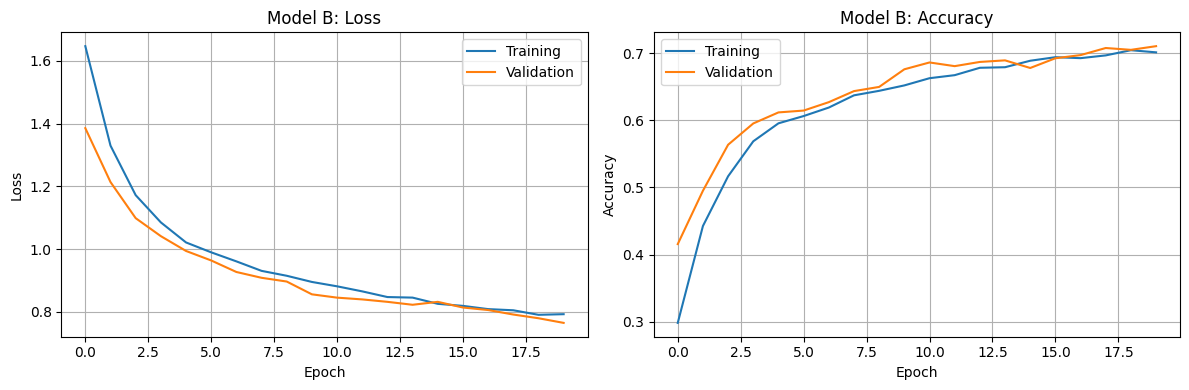

Final training accuracy: 70.12%
Final validation accuracy: 71.04%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(history_b.history[metric], label="Training")
    ax.plot(history_b.history[f"val_{metric}"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Model B: {metric.capitalize()}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Final training accuracy: {history_b.history['accuracy'][-1]:.2%}")
print(f"Final validation accuracy: {history_b.history['val_accuracy'][-1]:.2%}")

## Model B Results and Comparison

After 20 epochs, Model B achieved 70.12% training accuracy and
71.04% validation accuracy. Model A achieved 84.14% training accuracy
and 81.76% validation accuracy under the same training settings.

Model B uses 47,261 trainable parameters compared with Model A's
389,958, a reduction of approximately 88%. Its validation accuracy
was 10.72 percentage points lower in this experiment.

The training and validation curves remain close, while both losses
continue decreasing. This suggests that Model B may benefit from
additional training or different hyperparameters; the curves do not
show clear overfitting in this run.

Validation accuracy being slightly higher than training accuracy is
consistent with dropout being active during training and disabled
during validation.

These results illustrate an accuracy-versus-model-size trade-off.
Computational cost, saved model size, and final test performance
still need to be measured.

## Optimizer Comparison on Model B

Adam, standard SGD, and SGD with momentum are compared using the
same architecture, initial weights, data splits, batch size, and
20-epoch training budget.

Both SGD variants use the same learning rate to examine the effect
of momentum. Model selection uses validation results.

In [25]:
import time
import numpy as np
import pandas as pd

def build_model_b():
    return keras.Sequential([
        keras.Input(shape=(64, 64, 3)),
        keras.layers.Rescaling(1.0 / 255),

        keras.layers.SeparableConv2D(
            32, 3, activation="relu", padding="same"
        ),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.SeparableConv2D(64, 3, activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.SeparableConv2D(128, 3, activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.SeparableConv2D(256, 3, activation="relu"),
        keras.layers.GlobalAveragePooling2D(),

        keras.layers.Dropout(0.4),
        keras.layers.Dense(len(labels), activation="softmax"),
    ], name="model_b")

In [26]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.seconds = []

    def on_epoch_begin(self, epoch, logs=None):
        self.started_at = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.seconds.append(time.perf_counter() - self.started_at)


optimizer_factories = {
    "Adam": lambda: keras.optimizers.Adam(learning_rate=0.0005),
    "SGD": lambda: keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.0
    ),
    "SGD + Momentum": lambda: keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.9
    ),
}

# Reuse identical starting weights across all three experiments.
keras.utils.set_random_seed(42)
initial_model = build_model_b()
initial_weights = initial_model.get_weights()
del initial_model

optimizer_models = {}
optimizer_histories = {}
optimizer_results = []

In [30]:
checkpoint_dir = os.path.join(
    "Best_CNN_models", "optimizer_comparison"
)
os.makedirs(checkpoint_dir, exist_ok=True)

for name, make_optimizer in optimizer_factories.items():
    print(f"\nTraining Model B with {name}")

    keras.utils.set_random_seed(42)
    candidate = build_model_b()
    candidate.set_weights(initial_weights)

    candidate.compile(
        optimizer=make_optimizer(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    timer = EpochTimer()
    filename = name.lower().replace(" + ", "_").replace(" ", "_")
    checkpoint_path = os.path.join(
        checkpoint_dir, f"model_b_{filename}.keras"
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    )

    run = candidate.fit(
        train_x,
        train_y,
        epochs=20,
        batch_size=64,
        validation_data=(val_x, val_y),
        callbacks=[timer, checkpoint],
        shuffle=True,
        verbose=2,
    )

    values = run.history
    best_index = int(np.argmax(values["val_accuracy"]))

    optimizer_histories[name] = values
    optimizer_models[name] = keras.models.load_model(checkpoint_path)

    optimizer_results.append({
        "Optimizer": name,
        "Learning rate": 0.0005 if name == "Adam" else 0.01,
        "Momentum": (
            np.nan if name == "Adam"
            else 0.9 if name == "SGD + Momentum"
            else 0.0
        ),
        "Best epoch": best_index + 1,
        "Best validation accuracy": values["val_accuracy"][best_index],
        "Validation loss at best epoch": values["val_loss"][best_index],
        "Final training accuracy": values["accuracy"][-1],
        "Final validation accuracy": values["val_accuracy"][-1],
        "Mean seconds per epoch": np.mean(timer.seconds),
    })

print(f"\nCompleted experiments: {len(optimizer_results)}")


Training Model B with Adam
Epoch 1/20
187/187 - 14s - 77ms/step - accuracy: 0.2674 - loss: 1.6816 - val_accuracy: 0.3843 - val_loss: 1.4364
Epoch 2/20
187/187 - 12s - 65ms/step - accuracy: 0.4376 - loss: 1.3680 - val_accuracy: 0.4787 - val_loss: 1.2938
Epoch 3/20
187/187 - 12s - 64ms/step - accuracy: 0.4929 - loss: 1.2338 - val_accuracy: 0.5307 - val_loss: 1.1907
Epoch 4/20
187/187 - 12s - 64ms/step - accuracy: 0.5408 - loss: 1.1393 - val_accuracy: 0.5910 - val_loss: 1.0828
Epoch 5/20
187/187 - 22s - 115ms/step - accuracy: 0.5790 - loss: 1.0692 - val_accuracy: 0.6266 - val_loss: 1.0203
Epoch 6/20
187/187 - 13s - 68ms/step - accuracy: 0.5920 - loss: 1.0335 - val_accuracy: 0.6368 - val_loss: 0.9884
Epoch 7/20
187/187 - 20s - 108ms/step - accuracy: 0.6047 - loss: 1.0018 - val_accuracy: 0.6470 - val_loss: 0.9628
Epoch 8/20
187/187 - 12s - 63ms/step - accuracy: 0.6174 - loss: 0.9809 - val_accuracy: 0.6552 - val_loss: 0.9392
Epoch 9/20
187/187 - 11s - 59ms/step - accuracy: 0.6299 - loss: 0.

In [31]:
optimizer_comparison = pd.DataFrame(optimizer_results).sort_values(
    "Best validation accuracy",
    ascending=False,
).reset_index(drop=True)

display(optimizer_comparison.style.format({
    "Learning rate": "{:.5f}",
    "Momentum": "{:.1f}",
    "Best validation accuracy": "{:.2%}",
    "Validation loss at best epoch": "{:.4f}",
    "Final training accuracy": "{:.2%}",
    "Final validation accuracy": "{:.2%}",
    "Mean seconds per epoch": "{:.2f}",
}, na_rep="-"))

optimizer_comparison.to_csv(
    os.path.join(checkpoint_dir, "optimizer_results.csv"),
    index=False,
)

,Optimizer,Learning rate,Momentum,Best epoch,Best validation accuracy,Validation loss at best epoch,Final training accuracy,Final validation accuracy,Mean seconds per epoch
0,Adam,0.00050,-,20,70.18%,0.7884,69.32%,70.18%,12.87
1,SGD,0.01000,0.0,1,17.81%,1.7910,17.83%,17.81%,10.88
2,SGD + Momentum,0.01000,0.9,1,17.34%,1.7908,17.68%,17.34%,11.08


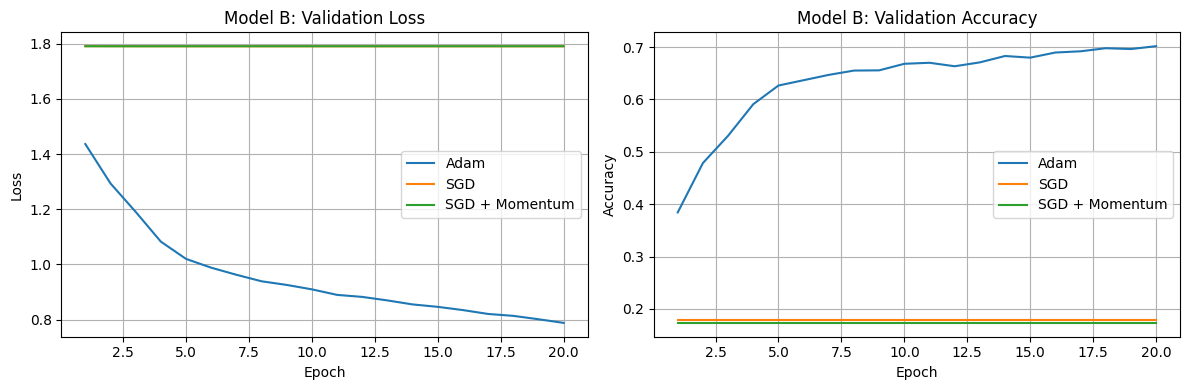

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, values in optimizer_histories.items():
    epochs = range(1, len(values["val_loss"]) + 1)

    axes[0].plot(epochs, values["val_loss"], label=name)
    axes[1].plot(epochs, values["val_accuracy"], label=name)

axes[0].set_title("Model B: Validation Loss")
axes[0].set_ylabel("Loss")

axes[1].set_title("Model B: Validation Accuracy")
axes[1].set_ylabel("Accuracy")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [33]:
selected_optimizer_b = optimizer_comparison.iloc[0]["Optimizer"]
selected_model_b = optimizer_models[selected_optimizer_b]

print(f"Selected optimizer: {selected_optimizer_b}")
print(
    "Best validation accuracy: "
    f"{optimizer_comparison.iloc[0]['Best validation accuracy']:.2%}"
)

Selected optimizer: Adam
Best validation accuracy: 70.18%


In [34]:
# Additional SGD learning-rate experiments.
# Existing optimizer_results, models, and histories are preserved.
extra_optimizer_factories = {
    "SGD lr=0.001": lambda: keras.optimizers.SGD(
        learning_rate=0.001, momentum=0.0
    ),
    "SGD lr=0.1": lambda: keras.optimizers.SGD(
        learning_rate=0.1, momentum=0.0
    ),
    "Momentum lr=0.001": lambda: keras.optimizers.SGD(
        learning_rate=0.001, momentum=0.9
    ),
    "Momentum lr=0.1": lambda: keras.optimizers.SGD(
        learning_rate=0.1, momentum=0.9
    ),
}

extra_checkpoint_dir = os.path.join(
    "Best_CNN_models", "sgd_learning_rate_comparison"
)
os.makedirs(extra_checkpoint_dir, exist_ok=True)

for name, make_optimizer in extra_optimizer_factories.items():
    print(f"\nTraining Model B with {name}")

    keras.utils.set_random_seed(42)
    candidate = build_model_b()
    candidate.set_weights(initial_weights)

    candidate.compile(
        optimizer=make_optimizer(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    timer = EpochTimer()
    filename = name.lower().replace(" ", "_").replace("=", "_")
    checkpoint_path = os.path.join(
        extra_checkpoint_dir, f"model_b_{filename}.keras"
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    )

    run = candidate.fit(
        train_x,
        train_y,
        epochs=20,
        batch_size=64,
        validation_data=(val_x, val_y),
        callbacks=[timer, checkpoint],
        shuffle=True,
        verbose=2,
    )

    values = run.history
    best_index = int(np.argmax(values["val_accuracy"]))

    optimizer_histories[name] = values
    optimizer_models[name] = keras.models.load_model(checkpoint_path)

    # Replace this experiment's previous row if this cell is rerun.
    optimizer_results[:] = [
        row for row in optimizer_results
        if row["Optimizer"] != name
    ]

    optimizer_results.append({
        "Optimizer": name,
        "Learning rate": float(
            keras.backend.get_value(candidate.optimizer.learning_rate)
        ),
        "Momentum": float(candidate.optimizer.momentum),
        "Best epoch": best_index + 1,
        "Best validation accuracy": values["val_accuracy"][best_index],
        "Validation loss at best epoch": values["val_loss"][best_index],
        "Final training accuracy": values["accuracy"][-1],
        "Final validation accuracy": values["val_accuracy"][-1],
        "Mean seconds per epoch": np.mean(timer.seconds),
    })

optimizer_comparison = pd.DataFrame(optimizer_results).sort_values(
    "Best validation accuracy", ascending=False
).reset_index(drop=True)

display(optimizer_comparison)

optimizer_comparison.to_csv(
    os.path.join(extra_checkpoint_dir, "combined_optimizer_results.csv"),
    index=False,
)


Training Model B with SGD lr=0.001
Epoch 1/20
187/187 - 13s - 68ms/step - accuracy: 0.1800 - loss: 1.7917 - val_accuracy: 0.1789 - val_loss: 1.7916
Epoch 2/20
187/187 - 11s - 61ms/step - accuracy: 0.1802 - loss: 1.7916 - val_accuracy: 0.1781 - val_loss: 1.7915
Epoch 3/20
187/187 - 11s - 60ms/step - accuracy: 0.1784 - loss: 1.7915 - val_accuracy: 0.1781 - val_loss: 1.7914
Epoch 4/20
187/187 - 11s - 60ms/step - accuracy: 0.1783 - loss: 1.7914 - val_accuracy: 0.1781 - val_loss: 1.7913
Epoch 5/20
187/187 - 12s - 62ms/step - accuracy: 0.1783 - loss: 1.7913 - val_accuracy: 0.1781 - val_loss: 1.7913
Epoch 6/20
187/187 - 11s - 60ms/step - accuracy: 0.1783 - loss: 1.7912 - val_accuracy: 0.1781 - val_loss: 1.7912
Epoch 7/20
187/187 - 11s - 59ms/step - accuracy: 0.1783 - loss: 1.7912 - val_accuracy: 0.1781 - val_loss: 1.7911
Epoch 8/20
187/187 - 11s - 57ms/step - accuracy: 0.1783 - loss: 1.7911 - val_accuracy: 0.1781 - val_loss: 1.7911
Epoch 9/20
187/187 - 11s - 57ms/step - accuracy: 0.1783 - lo

,Optimizer,Learning rate,Momentum,Best epoch,Best validation accuracy,Validation loss at best epoch,Final training accuracy,Final validation accuracy,Mean seconds per epoch
0,Adam,0.0005,NaN,20,0.701761,0.788423,0.693198,0.701761,12.874321
1,SGD lr=0.001,0.0010,0.0,1,0.178865,1.791613,0.178311,0.178082,11.064288
2,SGD,0.0100,0.0,1,0.178082,1.791038,0.178311,0.178082,10.878416
3,Momentum lr=0.001,0.0010,0.9,1,0.178082,1.791002,0.178311,0.178082,11.671577
4,SGD + Momentum,0.0100,0.9,1,0.173386,1.790840,0.176801,0.173386,11.081857
5,SGD lr=0.1,0.1000,0.0,1,0.173386,1.790792,0.175543,0.173386,11.136329
6,Momentum lr=0.1,0.1000,0.9,1,0.154599,1.797702,0.172356,0.154599,11.385104


In [35]:
for name in ["SGD lr=0.001", "SGD lr=0.1"]:
    if name not in optimizer_models:
        print(f"{name}: run has not finished yet")
        continue

    probabilities = optimizer_models[name].predict(
        val_x, batch_size=64, verbose=0
    )
    predictions = probabilities.argmax(axis=1)

    print(f"\n{name}")
    print("Predicted class counts:", dict(zip(
        labels,
        np.bincount(predictions, minlength=len(labels)),
    )))
    print("Probability variation:", probabilities.std(axis=0))


SGD lr=0.001
Predicted class counts: {'buildings': 0, 'forest': 0, 'glacier': 21, 'mountain': 2534, 'sea': 0, 'street': 0}
Probability variation: [1.7367323e-05 1.0940057e-05 3.1073821e-05 1.4141955e-05 1.2943557e-05
 8.7293975e-06]

SGD lr=0.1
Predicted class counts: {'buildings': 0, 'forest': 0, 'glacier': 2555, 'mountain': 0, 'sea': 0, 'street': 0}
Probability variation: [9.4134120e-06 3.7103234e-06 1.1424230e-05 1.3639299e-05 5.5445871e-06
 8.3774039e-06]


## Hyperparameter tuning

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    hp_learn_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2,sampling='log')
    hp_drop_rate = hp.Float("drop_rate", min_value=0, max_value=1, step=0.1)

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(hp_drop_rate))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    metrics = hp.Choice("metrics", values=["accuracy", "categorical_accuracy"])

    optimizer = keras.optimizers.Adam(learning_rate=hp_learn_rate)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=[metrics])
    
    return model

In [4]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection2",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

Reloading Tuner from CNN_search/Model_selection2/tuner0.json


I0000 00:00:1790141765.226628  875123 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Choosing the top 10 models for further tuning

In [5]:
best_params = tuner.get_best_hyperparameters(10)
best_models = tuner.get_best_models(10)

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)


In [ ]:
params_df = []
for i, param in enumerate(best_params):
    loss, accuracy = best_models[i].evaluate(test_x, test_y, verbose=0)

    params_df.append({"name": f"model{i}",
                      "model": best_models[i] ,
                      "param": param,
                      "loss": loss,
                      "accuracy": accuracy,
                      "learning_rate": param["learning_rate"],
                      "drop_rate" : param["drop_rate"],
                      "metric": param["metrics"]})

params_df = pd.DataFrame(params_df).sort_values("accuracy", ascending=False, ignore_index=True)

params_df

,name,model,param,loss,accuracy,learning_rate,drop_rate,metric
0,model5,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.524637,0.810333,0.000447,0.1,accuracy
1,model0,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.568092,0.808667,0.000447,0.6,accuracy
2,model7,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.554908,0.806333,0.000447,0.4,accuracy
3,model1,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.561818,0.806000,0.000891,0.4,accuracy
4,model2,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.583540,0.804333,0.000891,0.0,accuracy
5,model8,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.586864,0.802667,0.000224,0.0,accuracy
6,model9,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.577724,0.801000,0.000447,0.3,accuracy
7,model3,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.581876,0.794000,0.000447,0.7,accuracy
8,model4,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.589521,0.791667,0.000891,0.5,accuracy
9,model6,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.604857,0.787333,0.000891,0.7,accuracy


Top 6 models are chosen to fine tune

In [76]:
models = []
histories = []
top = 6
progress = tqdm(None, "Model", top, initial=0)
for i, params in params_df.iterrows():
    models.append(build_model(params["param"]))
    histories.append(models[-1].fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=0))
    if i >= top:
        break
    progress.update()

Model: 100%|██████████| 6/6 [02:44<00:00, 27.20s/it]

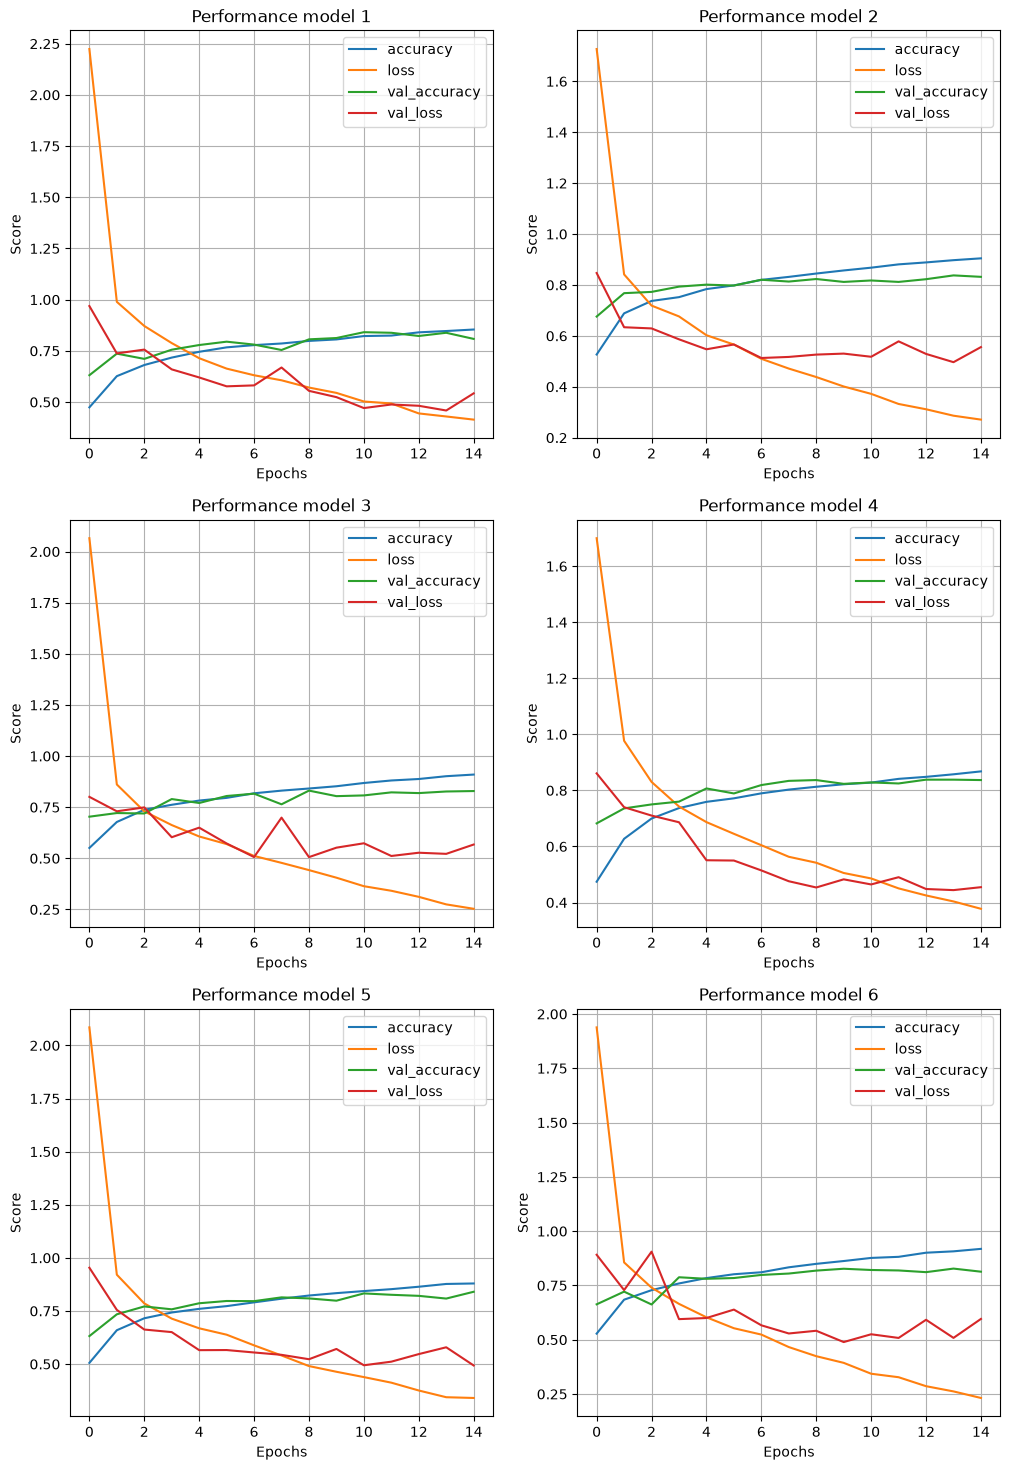

In [17]:
plt.figure(figsize=(12,18))
for i, history in enumerate(histories):
    plt.subplot(3,2,i+1)
    for key in history.history.keys():
        plt.plot(history.history[key], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(f"Performance model {i+1}")
    plt.grid()
    plt.legend()

plt.show()

In [21]:
for i, model in enumerate(best_models[:top]):
    model.save(os.path.join(os.curdir, "CNN_models", "best_models", f"model{i}.keras"), overwrite=True)

# With Dense layers

In [3]:
def build_model(hp):
    model = keras.Sequential()
    hp_drop_rate = hp.Choice("drop_rate", values=[0.0, 0.4, 0.7, 0.1, 0.6])

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    hp_layers = hp.Int("layer", min_value=0, max_value=3, step=1)
    units = {}
    dropouts = {}

    for i in range(1, 4):
        with hp.conditional_scope("layer", list(range(i, 4))):
            units[i] = hp.Choice(
                f"unit{i}",
                values=[32, 64, 128, 256, 512],
            )
            dropouts[i] = hp.Float(
                f"drop{i}",
                min_value=0.1,
                max_value=0.9,
                step=0.1,
            )

    for i in range(hp_layers, 0, -1):
        model.add(keras.layers.Dense(units[i], activation="relu"))
        model.add(keras.layers.Dropout(dropouts[i]))

    model.add(keras.layers.Dropout(hp_drop_rate))

    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=0.000447)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [ ]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection3",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

Trial 1521 Complete [00h 00m 17s]
val_accuracy: 0.7827635407447815

Best val_accuracy So Far: 0.8311966061592102
Total elapsed time: 2d 03h 55m 16s

Search: Running Trial #1522

Value             |Best Value So Far |Hyperparameter
0                 |0                 |drop_rate
2                 |2                 |layer
0.6               |0.4               |drop1
256               |256               |unit1
0.9               |0.2               |drop2
256               |512               |unit2

Epoch 1/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2653 - loss: 2.0468

# With BatchNormalize

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    hp_learn_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2,sampling='log')
    hp_drop_rate = hp.Float("drop_rate", min_value=0, max_value=1, step=0.1)

    

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(hp_drop_rate))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=hp_learn_rate)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [ ]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection4",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

In [ ]:
best_params = tuner.get_best_hyperparameters(10)
best_models = tuner.get_best_models(10)

In [ ]:
params_df = []
for i, param in enumerate(best_params):
    loss, accuracy = best_models[i].evaluate(test_x, test_y, verbose=0)

    params_df.append({"name": f"model{i}",
                      "model": best_models[i] ,
                      "param": param,
                      "loss": loss,
                      "accuracy": accuracy,
                      "learning_rate": param["learning_rate"],
                      "drop_rate" : param["drop_rate"]})

params_df = pd.DataFrame(params_df).sort_values("accuracy", ascending=False, ignore_index=True)

params_df

In [ ]:
models = []
histories = []
top = 6
progress = tqdm(None, "Model", top, initial=0)
for i, params in params_df.iterrows():
    models.append(build_model(params["param"]))
    histories.append(models[-1].fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=0))
    if i >= top:
        break
    progress.update()

In [ ]:
plt.figure(figsize=(12,18))
for i, history in enumerate(histories):
    plt.subplot(3,2,i+1)
    for key in history.history.keys():
        plt.plot(history.history[key], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(f"Performance model {i+1}")
    plt.grid()
    plt.legend()

plt.show()

In [ ]:
for i, model in enumerate(best_models[:top]):
    model.save(os.path.join(os.curdir, "Best_CNN_models", "CNN_BatchNormalize", f"model{i}.keras"), overwrite=True)